# 08 — Appearance descriptors: the rulers

Notebook 07 ended on a question. Of 536 images the estimator scored as at most
lightly degraded, 214 fail at the detection task — and in the sample grids some of
those failures announce themselves (a sepia dust storm, a near-black street) while
many look unremarkable. The question this study turns on is whether the failures
can be told apart from the genuinely clear images IN ADVANCE, from appearance
alone. Answering it needs rulers: appearance descriptors, each aimed at one way a
scene could announce trouble.

Five are defined in src/features.py, from first principles, with sources:
- **median brightness** — median of the value channel (0–255). Robust to headlights
  and lamps that inflate mean brightness; separates genuinely dark scenes from
  night-in-disguise (night handling left open in Bronte et al., 2009).
- **orange index** — mean(R) − mean(B). Dust scatters blue more than red, so a warm
  cast marks the per-channel airlight of sand/dust (Wei et al., 2025).
- **channel spread** — max − min of channel means. Colour cast of any hue.
- **RMS contrast** — std of grey intensity / 255 (Peli, 1990). The veil compresses
  the intensity range.
- **upper-region contrast** — RMS contrast of the top half of the frame: the far
  field, where fog suppresses contrast first. A fog witness independent of the dark
  channel (Bronte et al., 2009; Hautière et al., 2006) — later the arbiter of
  whether unremarkable-looking failures are genuinely foggy.

The working set is the 536 labelled low-severity images (notebook 07). It descends
from the cleaned dataset, so the greyscale file artifacts that would poison colour
descriptors are already excluded. Each descriptor is validated the same way before
it is trusted: by looking at the images at its extremes.

In [ ]:
# Setup: load the stage-1 labels, pull the repo, verify the five descriptors.
import os
import sys
import importlib
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

RAW_RTTS_DIR = "/content/drive/MyDrive/adaptive_perception_data/raw/RTTS"
OUTPUT_ROOT = "/content/drive/MyDrive/perception-difficulty-dve/results"
TABLES_DIR = os.path.join(OUTPUT_ROOT, "tables")
FIGURES_DIR = os.path.join(OUTPUT_ROOT, "figures")
IMAGES_DIR = RAW_RTTS_DIR

REPO_ROOT = "/content/perception-difficulty-dve"
REPO_URL = "https://github.com/aaaraafaat/perception-difficulty-dve.git"
if not os.path.isdir(REPO_ROOT):
    os.system(f"git clone {REPO_URL} {REPO_ROOT}")
os.system(f"cd {REPO_ROOT} && git pull")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)
import src.features as feat
importlib.reload(feat)

DESCRIPTORS = ["median_brightness_score", "orange_index_score",
               "channel_spread_score", "rms_contrast_score", "upper_contrast_score"]

missing = [name for name in DESCRIPTORS if not hasattr(feat, name)]
if missing:
    raise ImportError(f"features.py missing {missing} — push from Cursor, rerun.")

labels = pd.read_csv(os.path.join(TABLES_DIR, "failure_labels_RTTS.csv"))
print(f"labelled low-severity images: {len(labels)}")
print(labels["group"].value_counts().to_string())

Mounted at /content/drive
labelled low-severity images: 536
group
intermediate    219
failure         214
clear           103


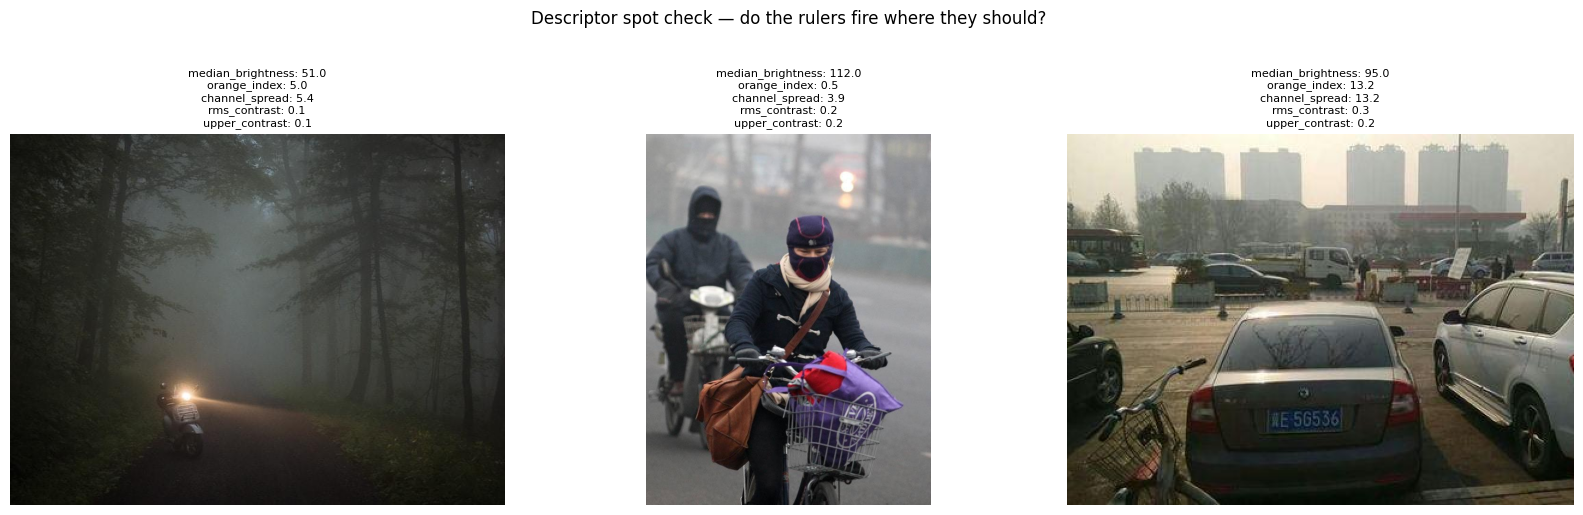

In [ ]:
# Spot check before the batch: three known images, all five descriptors under
# each. The orange scene must spike orange_index and channel_spread; the night
# scene must floor median_brightness; the unremarkable scene should sit
# mid-range on everything.
spot = pd.concat([
    labels[labels["group"] == "failure"].nsmallest(3, "recall_mean").head(2),
    labels[labels["group"] == "failure"].sample(1, random_state=3),
])

fig, axes = plt.subplots(1, len(spot), figsize=(5.5 * len(spot), 5))
for ax, (_, row) in zip(np.atleast_1d(axes), spot.iterrows()):
    image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
    values = {name: getattr(feat, name)(image_bgr) for name in DESCRIPTORS}
    ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title("\n".join(f"{k.replace('_score','')}: {v:.1f}" for k, v in values.items()),
                 fontsize=8)
    ax.axis("off")
fig.suptitle("Descriptor spot check — do the rulers fire where they should?", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Compute the five descriptors for the 536 labelled images; save one table.
records = []
for count, (_, row) in enumerate(labels.iterrows(), start=1):
    image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
    if image_bgr is None:
        continue
    values = {name: getattr(feat, name)(image_bgr) for name in DESCRIPTORS}
    values["stem"] = row["stem"]
    records.append(values)
    if count % 100 == 0:
        print(f"  {count} / {len(labels)}")

descriptors = labels.merge(pd.DataFrame(records), on="stem", how="inner")
descriptors_path = os.path.join(TABLES_DIR, "lowsev_descriptors_RTTS.csv")
descriptors.to_csv(descriptors_path, index=False)
print(f"Saved {len(descriptors)} rows to {descriptors_path}")
print(descriptors[DESCRIPTORS].describe().round(2).to_string())

  100 / 536
  200 / 536
  300 / 536
  400 / 536
  500 / 536
Saved 536 rows to /content/drive/MyDrive/perception-difficulty-dve/results/tables/lowsev_descriptors_RTTS.csv
       median_brightness_score  orange_index_score  channel_spread_score  rms_contrast_score  upper_contrast_score
count                   536.00              536.00                536.00              536.00                536.00
mean                     97.00               11.07                 19.66                0.22                  0.21
std                      26.56               31.05                 26.74                0.06                  0.08
min                      17.00              -65.64                  0.34                0.07                  0.03
25%                      79.00               -1.09                  4.33                0.18                  0.15
50%                      96.00                4.97                  9.64                0.22                  0.20
75%                     1

In [ ]:
# Validation by eye: for each descriptor, the five lowest and five highest
# images. A ruler is trusted only if its extremes look like what it claims
# to measure.
def show_descriptor_extremes(dataframe, descriptor_name):
    """One strip: 5 lowest then 5 highest images of one descriptor."""
    ranked = dataframe.sort_values(descriptor_name)
    selected = pd.concat([ranked.head(5), ranked.tail(5)])
    fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
    for ax, (_, row) in zip(axes.ravel(), selected.iterrows()):
        image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
        ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row[descriptor_name]:.1f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{descriptor_name} — lowest five (top row) to highest five (bottom row)",
                 fontsize=12, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    figure_path = os.path.join(FIGURES_DIR, f"fig_24_range_{descriptor_name.replace('_score','')}.jpg")
    plt.savefig(figure_path, dpi=95, format="jpg", bbox_inches="tight")
    print("Saved:", figure_path)
    plt.show()

for name in DESCRIPTORS:
    show_descriptor_extremes(descriptors, name)

In [ ]:
# Redundancy among the five descriptors: Spearman correlation of every pair.
# Near ±1 = one of the pair is redundant.
corr = descriptors[DESCRIPTORS].corr(method="spearman").round(2)
print(corr.to_string())

                         median_brightness_score  orange_index_score  channel_spread_score  rms_contrast_score  upper_contrast_score
median_brightness_score                     1.00                0.13                  0.17                0.06                 -0.04
orange_index_score                          0.13                1.00                  0.48               -0.20                 -0.07
channel_spread_score                        0.17                0.48                  1.00               -0.14                 -0.26
rms_contrast_score                          0.06               -0.20                 -0.14                1.00                  0.80
upper_contrast_score                       -0.04               -0.07                 -0.26                0.80                  1.00


### Correlation Heatmap

This heatmap visualizes the Spearman correlation coefficients between each pair of descriptors. Values closer to 1 or -1 indicate a stronger positive or negative linear relationship, respectively, while values closer to 0 suggest a weaker relationship.

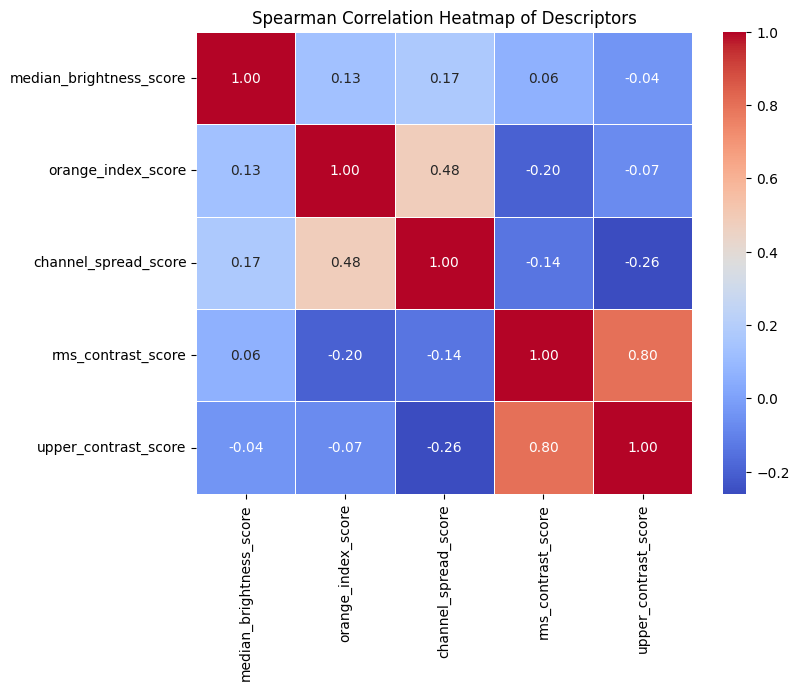

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Spearman Correlation Heatmap of Descriptors')
plt.show()

In [ ]:
# First look: descriptor medians per task-outcome group. Formal overlap
# testing is notebook 09's job; this only orients the eye.
print(descriptors.groupby("group")[DESCRIPTORS].median().round(1).to_string())

              median_brightness_score  orange_index_score  channel_spread_score  rms_contrast_score  upper_contrast_score
group                                                                                                                    
clear                            92.0                 2.4                   6.5                 0.2                   0.2
failure                         100.0                 7.3                  14.4                 0.2                   0.2
intermediate                     96.0                 4.9                   8.3                 0.2                   0.2


## Notebook summary — five validated descriptors

Five appearance descriptors were computed on the 536 labelled low-severity images
and validated by inspecting their extremes (fig_24 strips): median brightness
(grey luminance; low = night driving, high = bright daylight — robust to headlights),
orange index (low = blue-cast scenes, high = orange sandstorms), channel spread
(low = achromatic, high = strong single-hue cast), RMS contrast (low = whiteout,
high = structured), and upper-region contrast (low = far-field erased by fog, high =
visible horizon; the fog witness independent of the dark channel, Bronte et al.
2009). Each ruler measures what its name claims.

The descriptors are non-redundant (fig_25): the only strong correlation is RMS vs
upper-region contrast (0.80, expected — shared machinery, but the upper region
carries fog-specific information); orange index and channel spread correlate only
moderately (0.48 — they share the orange high end but split on blue vs grey), and
median brightness is independent of all colour and contrast measures.

A first look at group medians is already suggestive: RMS contrast, upper-region
contrast, and median brightness are essentially equal across failure, intermediate,
and clear groups (contrast 0.2/0.2/0.2; upper 0.2/0.2/0.2; brightness 100/96/92 —
failures if anything slightly brighter, not darker). Only the colour descriptors
separate the groups (orange index 7.3 vs 2.4; channel spread 14.4 vs 6.5), and that
separation is driven by the flaggable coloured-dust minority. Whether any descriptor
or combination separates the failures once the flaggable modes are removed is the
formal question of notebook 09. Output: lowsev_descriptors_RTTS.csv, fig_24–25.
References: Peli (1990); Bronte et al. (2009); Hautière et al. (2006).